# Système de recommandation de mode utilisant les caractéristiques de l'image : processus que nous pouvons suivre

Créer un système de recommandation de mode utilisant des caractéristiques d'image implique plusieurs étapes clés, exploitant à la fois la vision par ordinateur et les techniques d'apprentissage automatique. Voici un processus détaillé pour créer un système de recommandation de mode utilisant des caractéristiques d'image :


1. Constituez un ensemble de données diversifié d'articles de mode. Cet ensemble de données doit inclure une grande variété d'articles de couleurs, de motifs, de styles et de catégories différents.

2. Assurez-vous que toutes les images sont dans un format (par exemple, JPEG, PNG) et une résolution cohérents.

3. Implémenter une fonction de prétraitement pour préparer les images à l’extraction de fonctionnalités.

4. Choisissez un modèle CNN pré-entraîné tel que VGG16, ResNet ou InceptionV3. Ces modèles, pré-entraînés sur de grands ensembles de données comme ImageNet, sont capables d'extraire de puissantes représentations de caractéristiques à partir d'images.

5. Passez chaque image via le modèle CNN pour extraire les fonctionnalités.

6. Définissez une métrique pour mesurer la similarité entre les vecteurs de caractéristiques.
7. Classez les images de l'ensemble de données en fonction de leur similitude avec l'image d'entrée et recommandez les N éléments les plus similaires.

8. Implémentez une fonction finale qui encapsule l’ensemble du processus depuis le prétraitement d’une image d’entrée, l’extraction des fonctionnalités, le calcul des similitudes et la sortie des recommandations.

Le processus commence par la collecte d'un ensemble de données d'images de tenues à la mode.

J'ai trouvé un ensemble de données idéal pour cette tâche. Vous pouvez le télécharger ici .https://statso.io/2024/02/04/fashion-recommendations-using-image-features-case-study/

Système de recommandation de mode utilisant des fonctionnalités d'image avec Python

In [1]:
from zipfile import ZipFile
import os

# Use raw strings for file paths to avoid issues with backslashes
zip_file_path = r'/content/de18b-women-fashion.zip'
extraction_directory = r'/content/women_fashion'

if not os.path.exists(extraction_directory):
    os.makedirs(extraction_directory)

with ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_directory)

extracted_files = os.listdir(extraction_directory)
print(extracted_files[:10])

FileNotFoundError: [Errno 2] No such file or directory: '/content/de18b-women-fashion.zip'

Dans le code ci-dessus, un fichier zip nommé  « women fashion.zip » ,  situé dans le chemin « /content/women fashion.zip » sur Google Colab, est extrait vers le répertoire spécifié : « /content/women_fashion/ ». Nous vérifions d'abord si le répertoire d'extraction existe ; s'il n'existe pas, nous le créons avec os.makedirs() . Ensuite, grâce au module Python ZipFile , le fichier zip est ouvert en lecture et son contenu est extrait vers le répertoire spécifié.

Le fichier zip contient un répertoire « mode féminine » et des métadonnées utilisées par macOS (__MACOSX). Ignorons les métadonnées macOS et concentrons-nous sur le répertoire « mode féminine » et listons son contenu pour comprendre les types et le nombre d'images dont nous disposons :

In [15]:
#correction du chemin pour inclure le repertoire <<mode feminine>> et lister son contenu
extracted_directory_updated = os.path.join(extraction_directory, 'women fashion')

# lister les fichiers dans le repertoire mise à jour
extracted_files_updated = os.listdir(extracted_directory_updated)
extracted_files_updated[:10], len(extracted_files_updated)

(['black dress with lace detailing.jpg',
  'tight-fitting, off-the-shoulder white dress 2.jpg',
  'dark blue, knee-length dress with thin straps.jpg',
  'vibrant blue and a neutral tone adorned with colorful floral patterns.jpg',
  'black lace bustier top paired with high-waisted black trousers.jpg',
  'fitted, ruched dress with a sweetheart neckline and long mesh sleeves.jpg',
  'burgundy off-the-shoulder dress with an asymmetrical hemline.jpg',
  'light brown sleeveless double-breasted blazer paired with matching straight-leg trousers.jpg',
  'ladies-party-wear-cotton-short-dress-full.jpg',
  'black top with spaghetti straps and a black skirt adorned with a fringe detail at the hem.jpg'],
 97)

Maintenant, regardons la première image de l’ensemble de données :

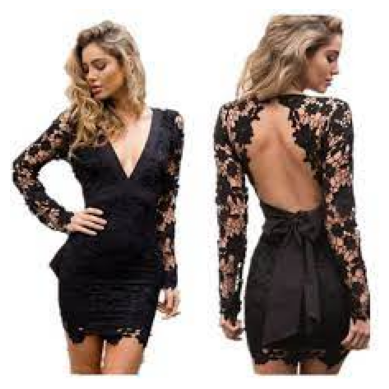

In [16]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

#fonction pour charger et afficher une image
def display_image(image_path):
        image = Image.open(image_path)
        plt.imshow(image)
        plt.axis('off')
        plt.show()

#afficher la premiere image pour comprendre ses caracteristiques
first_image_path = os.path.join(extracted_directory_updated, extracted_files_updated[0])
display_image(first_image_path)

Nous allons maintenant créer une liste de tous les chemins d'accès aux fichiers image qui seront utilisés plus tard pour extraire les fonctionnalités de chaque image de l'ensemble de données :

In [17]:
import glob
import os

#chemin du repertoire contenant vos image
image_directory = '/content/women_fashion/women fashion'

image_paths_list = [file for file in glob.glob(os.path.join(image_directory, '*.*')) if file.endswith(('.jpg', '.png', '.jpeg', 'webp'))]
#afficher la liste des chemins des fichiers image
print(image_paths_list)

['/content/women_fashion/women fashion/black dress with lace detailing.jpg', '/content/women_fashion/women fashion/tight-fitting, off-the-shoulder white dress 2.jpg', '/content/women_fashion/women fashion/dark blue, knee-length dress with thin straps.jpg', '/content/women_fashion/women fashion/vibrant blue and a neutral tone adorned with colorful floral patterns.jpg', '/content/women_fashion/women fashion/black lace bustier top paired with high-waisted black trousers.jpg', '/content/women_fashion/women fashion/fitted, ruched dress with a sweetheart neckline and long mesh sleeves.jpg', '/content/women_fashion/women fashion/burgundy off-the-shoulder dress with an asymmetrical hemline.jpg', '/content/women_fashion/women fashion/light brown sleeveless double-breasted blazer paired with matching straight-leg trousers.jpg', '/content/women_fashion/women fashion/ladies-party-wear-cotton-short-dress-full.jpg', '/content/women_fashion/women fashion/black top with spaghetti straps and a black sk

Dans le code ci-dessus, le module glob permet de générer une liste de chemins d'accès aux images stockées dans le répertoire. La fonction glob.glob recherche les fichiers correspondant à un modèle spécifié, dans ce cas, *.*, qui correspond à tous les fichiers du répertoire. La compréhension de liste filtre ensuite ces fichiers pour n'inclure que ceux portant des extensions d'image spécifiques (.jpg, .png, .jpeg, .webp).

Il garantit que image_paths_list contient uniquement les chemins vers les fichiers image, à l'exclusion de tout autre type de fichier pouvant être présent dans le répertoire.

Maintenant, nous allons extraire les caractéristiques de toutes les images de mode :

In [21]:
from PIL import Image
from tensorflow.keras.applications.vgg16 import  VGG16, preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.utils import load_img, img_to_array


base_model = VGG16(weights='imagenet', include_top=False)
model = Model(inputs=base_model.input, outputs=base_model.output)

def preprocess_image(image_path):
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array_expanded = np.expand_dims(img_array, axis=0)
    return preprocess_input(img_array_expanded)

def extract_features(model, preprocessed_img):
  features =model.predict(preprocessed_img)
  flattened_features = features.flatten()
  normalized_features = flattened_features / np.linalg.norm(flattened_features)
  return normalized_features

all_features = []
all_image_name = []

for img_path in image_paths_list:
  preprocessed_img = preprocess_image(img_path)
  features = extract_features(model, preprocessed_img)
  all_features.append(features)
  all_image_name.append(os.path.basename(img_path))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 595ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 569ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 553ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 578ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 563ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 858ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 742ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 604ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 563ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

Dans le code ci-dessus, un processus d'extraction de fonctionnalités est implémenté à l'aide du modèle VGG16, un réseau neuronal convolutif populaire pré-entraîné sur l'ensemble de données ImageNet, pour extraire des fonctionnalités visuelles des images stockées dans image_paths_list.

Initialement, le modèle VGG16 est chargé sans sa couche de classification supérieure (include_top=False), ce qui le rend plus adapté à l'extraction de caractéristiques qu'à la classification. Chaque chemin d'image de la liste image_paths_list est traité en plusieurs étapes : l'image est chargée et redimensionnée à 224 × 224 pixels pour correspondre aux exigences de taille d'entrée VGG16, convertie en tableau NumPy et prétraitée pour correspondre au format d'entrée attendu du modèle.

Les images prétraitées sont ensuite intégrées au modèle VGG16 pour en extraire les caractéristiques, qui sont ensuite aplaties et normalisées afin de créer un vecteur de caractéristiques cohérent pour chaque image. Ces vecteurs de caractéristiques (all_features) et leurs noms de fichiers d'images correspondants (all_image_names) sont stockés, fournissant ainsi un ensemble de données structuré pour les étapes suivantes de la création d'un système de recommandation de mode utilisant les caractéristiques des images.

Maintenant, je vais écrire une fonction pour recommander des images de mode en fonction des caractéristiques de l'image :

In [22]:
from scipy.spatial.distance import cosine

def recommend_fashion_items_cnn(input_image_path, all_features, all_image_names, model, top_n=5):
  #pretraiter l'image d'entree et extraire les caracteristiques
    preprocessed_img = preprocess_image(input_image_path)
    input_features = extract_features(model, preprocessed_img)

    #calculer les similitudes et trouver les N images similaires les plus importantes
    similarities = [1 - cosine(input_features, other_feature) for other_feature in all_features]
    similar_indices = np.argsort(similarities)[:top_n]

    #filtrer l'index de l'image d'entree à partir de similar_indices
    similar_indices = [idx for idx in similar_indices if idx != all_image_names.index(input_image_path)]

    #afficher l'image d'entrée
    plt.figure(figsize=(15, 10))
    plt.subplot(1, top_n + 1, 1)
    plt.imshow(Image.open(input_image_path))
    plt.axis('off')
    plt.title("Input Image")

    # afficher les images similaires
    for i , idx in enumerate(similar_indices[:top_n], start=1):
      image_paths = os.path.join('/content/women_fashion/women fashion', all_image_names[idx])
      plt.subplot(1, top_n + 1, i + 1)
      plt.imshow(Image.open(image_paths))
      plt.title(f"Recommendation {i}")
      plt.axis('off')

    plt.tight_layout()
    plt.show()

Dans le code ci-dessus, nous avons défini une fonction recommend_fashion_items_cnn qui recommande des articles de mode similaires à une image d'entrée donnée grâce à l'extraction de caractéristiques basée sur l'apprentissage profond. Elle utilise le modèle VGG16 pour extraire des vecteurs de caractéristiques de grande dimension des images et capturer ainsi leur essence visuelle.

Pour une image d'entrée spécifiée, la fonction prétraite l'image, extrait ses caractéristiques et calcule la similarité cosinus entre ce vecteur de caractéristiques et ceux des autres images du jeu de données (all_features). Elle classe ces images en fonction de leur similarité et sélectionne les N images les plus similaires à recommander, excluant explicitement l'image d'entrée de la liste des indices similaires.

Au final, la fonction visualisera l'image d'entrée et ses recommandations en les affichant.

Maintenant, voici comment nous pouvons utiliser cette fonction pour recommander des images en fonction d'un modèle similaire dans l'image d'entrée :

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step


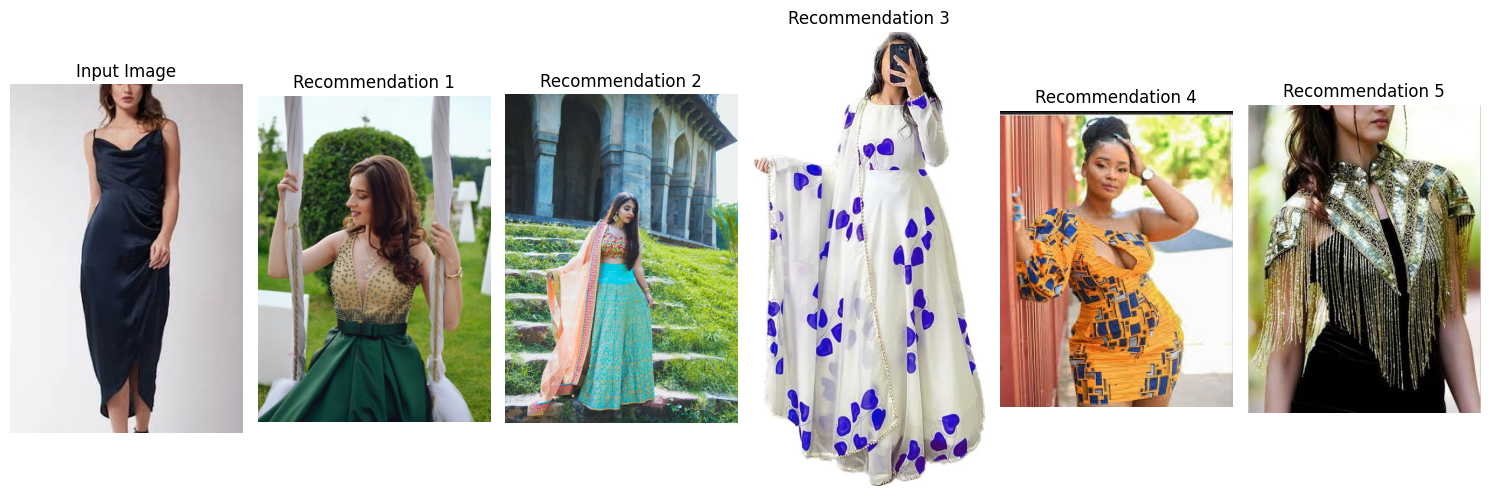

In [24]:
input_image_path = '/content/women_fashion/women fashion/dark, elegant, sleeveless dress that reaches down to about mid-calf.jpg'
recommend_fashion_items_cnn(input_image_path, all_features, image_paths_list, model, top_n= 5 )

Vous devez donner le chemin d'une image en entrée et vous verrez des recommandations de mode similaires en sortie.

# Résumé
Voici comment créer un système de recommandation de mode utilisant des caractéristiques d'image grâce au langage de programmation Python. Ce système exploite la vision par ordinateur et les techniques d'apprentissage automatique pour analyser les aspects visuels des articles de mode (couleur, texture et style) et recommander des produits similaires ou complémentaires aux utilisateurs.

